<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_3_(Exercise_3_2)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#  Imports and Reuse

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True,
                             download=True, transform=transform)
train_data = Subset(train_data, range(10000))
train_loader = DataLoader(train_data, batch_size=128,
                          shuffle=True, num_workers=0)

test_data = datasets.MNIST(root='./data', train=False,
                            download=True, transform=transform)
test_data = Subset(test_data, range(1000))
test_loader = DataLoader(test_data, batch_size=128,
                         shuffle=False, num_workers=0)

Using: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 64.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]


In [2]:
# Noise Schedule

T = 1000

def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas     = torch.linspace(beta_start, beta_end, T)
    alphas    = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return betas, alpha_bar

betas, alpha_bar = linear_schedule(T)
betas            = betas.to(device)
alpha_bar        = alpha_bar.to(device)

In [3]:
# Model Definition

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) *
            (np.log(10000) / (half - 1))
        )
        angles = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(angles),
                          torch.cos(angles)], dim=-1)


class SmallUNet(nn.Module):
    def __init__(self, t_emb_dim=128):
        super().__init__()
        self.t_emb = SinusoidalEmbedding(t_emb_dim)
        self.t_mlp = nn.Sequential(
            nn.Linear(t_emb_dim, t_emb_dim),
            nn.SiLU()
        )

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.GroupNorm(8, 32), nn.SiLU()
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, stride=2),
            nn.GroupNorm(8, 64), nn.SiLU()
        )

        self.t_proj1 = nn.Linear(t_emb_dim, 32 * 2)
        self.t_proj2 = nn.Linear(t_emb_dim, 64 * 2)
        self.t_proj3 = nn.Linear(t_emb_dim, 64 * 2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.GroupNorm(8, 64), nn.SiLU()
        )

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(64 + 64, 32, 2, stride=2),
            nn.GroupNorm(8, 32), nn.SiLU()
        )
        self.dec1 = nn.Sequential(
            nn.Conv2d(32 + 32, 1, 3, padding=1)
        )

    def apply_adagn(self, h, t_emb, proj):
        out         = proj(t_emb)
        scale, shift = out.chunk(2, dim=-1)
        scale       = scale.unsqueeze(-1).unsqueeze(-1)
        shift       = shift.unsqueeze(-1).unsqueeze(-1)
        return scale * h + shift

    def forward(self, x, t):
        t_emb = self.t_mlp(self.t_emb(t))

        h1 = self.enc1(x)
        h1 = self.apply_adagn(h1, t_emb, self.t_proj1)

        h2 = self.enc2(h1)
        h2 = self.apply_adagn(h2, t_emb, self.t_proj2)

        h  = self.bottleneck(h2)
        h  = self.apply_adagn(h, t_emb, self.t_proj3)

        h  = self.dec2(torch.cat([h, h2], dim=1))
        h  = self.dec1(torch.cat([h, h1], dim=1))
        return h

In [4]:
# Train Epsilon Model

def compute_targets(x0, t_idx, alpha_bar):
    ab  = alpha_bar[t_idx].view(-1, 1, 1, 1)
    eps = torch.randn_like(x0)
    x_t = (ab ** 0.5) * x0 + ((1 - ab) ** 0.5) * eps
    v   = (ab ** 0.5) * eps - ((1 - ab) ** 0.5) * x0
    return x_t, eps, v


def train_model(epochs=10):
    model     = SmallUNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        epoch_loss = 0
        for imgs, _ in train_loader:
            imgs  = imgs.to(device)
            B     = imgs.shape[0]
            t_idx = torch.randint(0, T, (B,), device=device)

            x_t, eps, _ = compute_targets(imgs, t_idx, alpha_bar)
            pred         = model(x_t, t_idx)
            loss         = criterion(pred, eps)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} "
              f"— Loss: {epoch_loss/len(train_loader):.6f}")

    return model


print("Training ε-prediction model...")
model_eps = train_model(epochs=10)
print("Done.")

Training ε-prediction model...
Epoch 1/10 — Loss: 0.223092
Epoch 2/10 — Loss: 0.063833
Epoch 3/10 — Loss: 0.051944
Epoch 4/10 — Loss: 0.046108
Epoch 5/10 — Loss: 0.041780
Epoch 6/10 — Loss: 0.039648
Epoch 7/10 — Loss: 0.038093
Epoch 8/10 — Loss: 0.038034
Epoch 9/10 — Loss: 0.036421
Epoch 10/10 — Loss: 0.036437
Done.


In [5]:
#  Compute Per-Timestep Loss

def compute_per_timestep_loss(model, loader, alpha_bar, T, n_batches=3):
    model.eval()
    criterion = nn.MSELoss()

    batches = []
    for i, (imgs, _) in enumerate(loader):
        if i >= n_batches:
            break
        batches.append(imgs.to(device))

    L_t = np.zeros(T)

    with torch.no_grad():
        for t_idx in range(T):
            losses_at_t = []
            for imgs in batches:
                B   = imgs.shape[0]
                t   = torch.full((B,), t_idx,
                                 dtype=torch.long, device=device)
                ab  = alpha_bar[t_idx].view(1, 1, 1, 1)
                eps = torch.randn_like(imgs)
                x_t = (ab ** 0.5) * imgs + ((1 - ab) ** 0.5) * eps

                pred = model(x_t, t)
                loss = criterion(pred, eps)
                losses_at_t.append(loss.item())

            L_t[t_idx] = np.mean(losses_at_t)

            if (t_idx + 1) % 100 == 0:
                print(f"  t={t_idx+1}/{T} "
                      f"— L_t = {L_t[t_idx]:.6f}")

    return L_t


print("Computing per-timestep loss...")
L_t = compute_per_timestep_loss(model_eps, test_loader,
                                alpha_bar, T, n_batches=3)
print("Done.")

Computing per-timestep loss...
  t=100/1000 — L_t = 0.079373
  t=200/1000 — L_t = 0.059197
  t=300/1000 — L_t = 0.049932
  t=400/1000 — L_t = 0.038252
  t=500/1000 — L_t = 0.020685
  t=600/1000 — L_t = 0.009202
  t=700/1000 — L_t = 0.004181
  t=800/1000 — L_t = 0.002950
  t=900/1000 — L_t = 0.001813
  t=1000/1000 — L_t = 0.001850
Done.


In [6]:
# Compute SNR Weighting

def compute_snr_weighting(alpha_bar, gamma=0.1):
    """
    LDAE Equation 15: λ_t = SNR(t)^γ
    """
    ab       = alpha_bar.cpu().numpy()
    snr      = ab / (1 - ab)
    weights  = snr ** gamma
    return snr, weights


snr_vals, snr_weights = compute_snr_weighting(alpha_bar, gamma=0.1)
t_range = np.arange(1, T + 1)

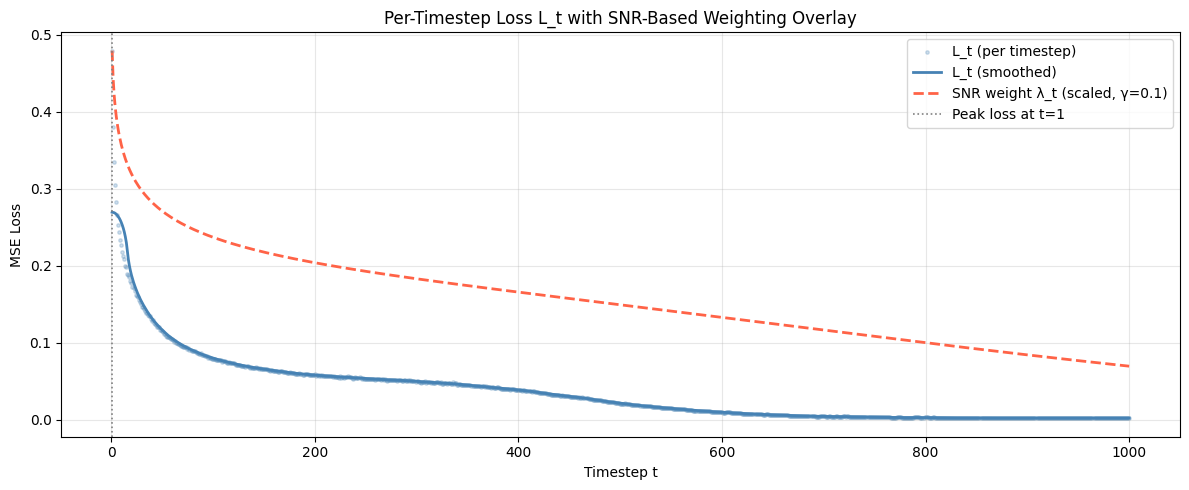


Peak loss at t = 1
SNR drops below 1.0 at t = 260


In [7]:
# Plot

L_t_smooth = uniform_filter1d(L_t, size=30)
snr_scaled = (snr_weights / snr_weights.max()) * L_t.max()

fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(t_range, L_t,
           alpha=0.25, s=6,
           color='steelblue', label='L_t (per timestep)')

ax.plot(t_range, L_t_smooth,
        color='steelblue', linewidth=2,
        label='L_t (smoothed)')

ax.plot(t_range, snr_scaled,
        color='tomato', linewidth=2,
        linestyle='--', label='SNR weight λ_t (scaled, γ=0.1)')

peak_t = np.argmax(L_t_smooth) + 1
ax.axvline(x=peak_t, color='gray', linestyle=':',
           linewidth=1.2, label=f'Peak loss at t={peak_t}')

ax.set_xlabel('Timestep t')
ax.set_ylabel('MSE Loss')
ax.set_title('Per-Timestep Loss L_t with SNR-Based Weighting Overlay')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_landscape_3_2.png', dpi=150)
plt.show()

print(f"\nPeak loss at t = {peak_t}")
print(f"SNR drops below 1.0 at t = "
      f"{int((snr_vals < 1.0).argmax() + 1)}")

# Some personal notes
```
1.
The per-timestep loss is simply:
L_t = E[||ε − ε_θ(x_t, t)||²]
Computed on a held-out batch at each specific t rather than averaged across random t.
```
```
2.
SNR-Based Loss Weighting — LDAE Equation 15
Source: LDAE paper — the specific weighting is:

λ_t = SNR(t)^γ      where γ = 0.1
SNR(t) = ᾱ_t / (1 − ᾱ_t)

This assigns higher weight to timesteps with higher SNR — meaning earlier, less noisy timesteps where the signal is still intact. The effect is to concentrate training on the region where meaningful features are recoverable. γ = 0.1 is a soft exponent — it doesn't completely ignore high-t timesteps, it just down-weights them gently.
The key insight connecting 3.1 to 3.2: ε-prediction already has stable gradients everywhere, but stable gradients at high-t timesteps are stable because the network is predicting near-zero — not because it's learning anything. SNR weighting fixes this by explicitly reducing the contribution of those timesteps to the total loss.              
```



# Interpretation

#### The per-timestep loss plot shows that L_t peaks sharply at t=1 and decreases monotonically toward t=1000 — the opposite of the naive expectation but consistent with a model that has learned the structure of ε-prediction. At low timesteps x_t ≈ x_0, meaning the noise ε is invisible in the input and fundamentally unrecoverable, so the network produces high loss not from poor training but from genuine irreducibility. At high timesteps x_t ≈ ε directly, making prediction trivially easy and driving loss toward zero. The SNR-based weighting from LDAE Equation 15 with γ=0.1 follows the same decreasing shape as L_t — both are highest at low t and decay together — which means the weighting is concentrating training budget on exactly the region where signal is intact and the prediction problem is hardest. Flat weighting λ_t=1 would assign equal importance to high-t timesteps where the network is essentially just outputting x_t and learning nothing about image structure, while SNR weighting correctly deprioritises those timesteps and focuses gradient updates on the recoverable signal region where representation learning actually occurs.

# More personal understanding notes -->

```
The trick is what the model is actually being asked to predict. Not the clean image. The noise ε.
This flips everything.

At Low t (Almost Clean Image)
x_t = √ᾱ_t · x_0  +  √(1−ᾱ_t) · ε
At t=1, ᾱ_t ≈ 1.0. So:
x_t ≈ x_0  +  (tiny amount) · ε
The noise ε was drawn from N(0,1) — it's a full scale random Gaussian. But it got multiplied by a tiny coefficient before being mixed in. So in x_t, the noise is buried and invisible under the clean image.
The network sees x_t which looks almost exactly like x_0. Now it must answer: "what exact N(0,1) noise vector was mixed into this?"
That is fundamentally impossible to answer well. The noise left almost no trace in x_t. There is no information in the input about what ε was. The network is being asked to recover a hidden signal it simply cannot see.
High loss — not because the model is bad. Because the problem is genuinely unsolvable.

At High t (Almost Pure Noise)
At t=999, ᾱ_t ≈ 0.0. So:
x_t ≈ (tiny amount) · x_0  +  √1 · ε  ≈  ε
x_t IS basically ε at this point. The clean image has been almost completely washed out.
The network sees x_t which looks almost exactly like ε. Now it must answer: "what noise was added?"
The answer is right there in the input. x_t ≈ ε, so just predict x_t.
Low loss — the answer is visible on the surface.
```

#### You are not predicting how much noise there is. You are predicting the exact noise vector. And the exact noise vector is only visible when it dominates the input.
#### Low loss at high t does not mean the model is learning something useful there — it means the answer is trivially readable from the input. SNR weighting exists precisely to stop the model from getting credit for that triviality.


